In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

In [25]:
# categories = [
#     'Complex\nGeometry', 
#     'Multi-Scale\nPhysics', 
#     'High\nDimensionality', 
#     'Strong\nNon-Linearity', 
#     'Oscillatory/\nStiff', 
#     'Inverse\nProblems'
# ]

categories = [
    'Сложная\nгеометрия', 
    'Многомасштаные\nзадачи', 
    'Высокая\nразмерность', 
    'Нелинейность', 
    'Осциллирующие\nрешения', 
    'Обратные\nзадачи'
]

In [46]:
data_sampling = [0.67, 0.09, 0.30, 0.00, 0.39, 0.80]
data_opt      = [0.25, 0.08, 0.80, 0.00, 0.31, 0.60]
data_arch     = [0.85, 0.24, 0.00, 0.78, 0.78, 0.78]

data = [data_sampling, data_opt, data_arch]
# labels = [
#     'Adv. Sampling',
#     'Optimizers',
#     'Architectures'
# ]
labels = [
    'Распределение точек коллокации',
    'Оптимизаторы',
    'Архитектуры'
]
colors = ['#4A90E2', '#D0021B', '#9013FE']

In [47]:
def radar_factory(num_vars, frame='circle'):
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarAxes(PolarAxes):
        name = 'radar'
        
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
            return lines

        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels, fontsize=8) # weight='bold'

        def _gen_axes_patch(self):
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars, radius=0.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

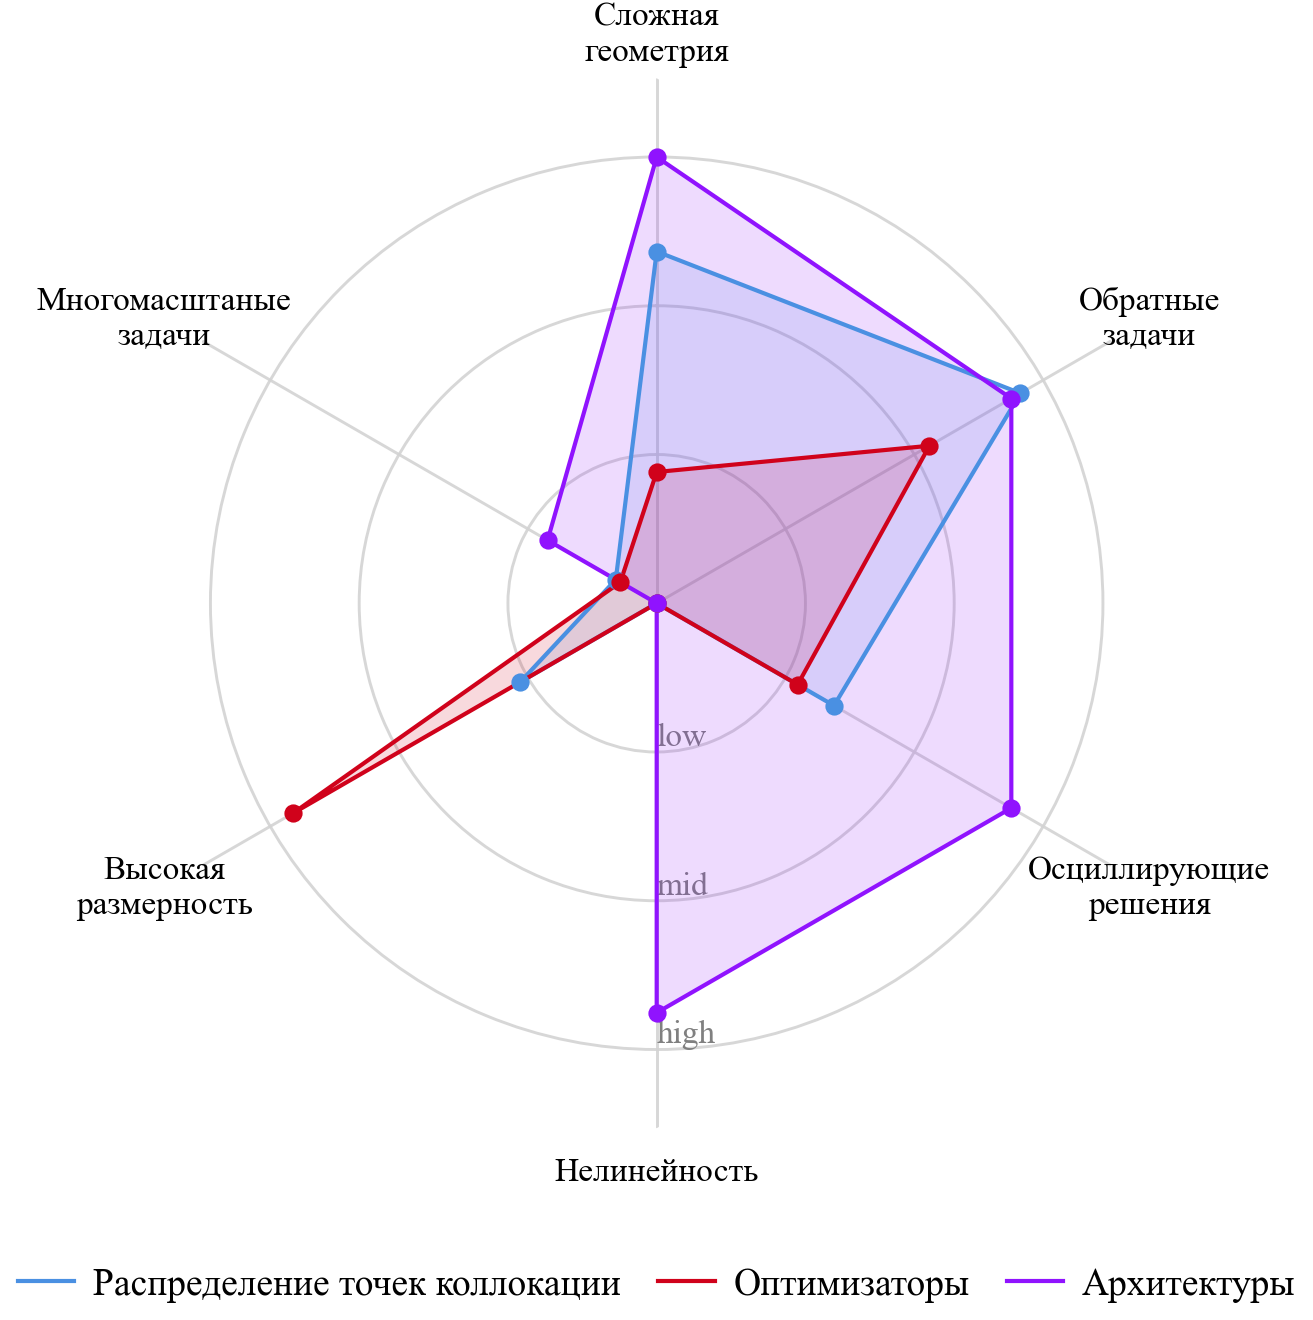

In [48]:
N = len(categories)
theta = radar_factory(N, frame='polygon')

fig, ax = plt.subplots(figsize=(6, 5), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(top=0.85, bottom=0.15, left=0.1, right=0.9)

rmax = max(max(d) for d in data)
ax.set_ylim(0, rmax * 1.05)
ax.set_rgrids([rmax/3, 2*rmax/3, rmax], labels=['low', 'mid', 'high'], angle=180, fontsize=8, color='gray')
ax.set_ylim(0, 1)

for d, color, label in zip(data, colors, labels):
    ax.plot(theta, d, color=color, linewidth=1.0, label=label)
    ax.fill(theta, d, facecolor=color, alpha=0.15)

ax.set_varlabels(categories)

for d, color in zip(data, colors):
    ax.scatter(theta, d, color=color, s=15, zorder=10)

# fig.text(
#     0.05, 0.92, 
#     "PINN Method Efficiency", 
#     fontsize=16, weight='bold', fontname='serif'
# )
# fig.text(
#     0.1, 0.99, 
#     "Эффективность методов улучшения PINN", 
#     fontsize=16, fontname='serif'  
# )

# fig.text(
#     0.05, 0.88,
#     "Relative Improvement over Vanilla (Log Scale)",
#     fontsize=10, color='gray', fontname='serif'
# )

# fig.text(
#     0.05, 0.88,
#     "Улучшение относительно базовой модели",
#     fontsize=10, color='gray', fontname='serif'
# )

legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=False, shadow=False, ncol=3, frameon=False, fontsize=9)

ax.spines['polar'].set_visible(False)
ax.grid(color='#D3D3D3', linestyle='-', linewidth=0.7, alpha=0.9)

plt.savefig('pinn_radar_chart.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.savefig('pinn_radar_chart.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [16]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

In [38]:
def create_pinnacle_diagram():
    fig, ax = plt.subplots(figsize=(12, 3))
    
    x_coords = [0, 4, 8, 12] 
    y_center = 0
    radius = 0.5
    
    color_circle = '#E84E38'   # Красно-оранжевый
    color_teal = '#1ABC9C'     # Бирюзовый для верхней стрелки
    color_box_edge = '#333333' # Цвет рамки
    color_text = '#222222'     # Цвет текста
    
    labels_math = [
        r'$\tilde{u}_{\tau}$',
        r'$u_{\tau}$',
        r'$u_{\mathcal{F}}$',
        r'$u$'
    ]
    
    box_x_min = x_coords[0] - 1.2
    box_x_max = x_coords[2] + 1.2
    box_y_min = y_center - 1.5
    box_y_max = y_center + 1.5
    
    rect = patches.Rectangle(
        (box_x_min, box_y_min), 
        box_x_max - box_x_min, 
        box_y_max - box_y_min,
        linewidth=1.5,
        edgecolor=color_box_edge,
        facecolor='none',
        zorder=1
    )
    ax.add_patch(rect)
    
    # Метка F в левом верхнем углу рамки
    ax.text(
        box_x_min + 0.2, 
        box_y_max - 0.2, 
        r'$\mathcal{F}$', 
        fontsize=20, 
        ha='left', 
        va='top'
    )

    # Стрелки соединяют центры кругов
    arrow_props = dict(
        arrowstyle='<|-|>',  # Двусторонняя стрелка
        mutation_scale=20,    # Размер наконечников
        color='#333333',
        linewidth=2.0,
        shrinkA=16, # Отступ от начала (чтобы не залезть на круг)
        shrinkB=16  # Отступ от конца
    )
    
    # Стрелка 1: u_tau_tilde <-> u_tau
    ax.annotate('', xy=(x_coords[0], y_center), xytext=(x_coords[1], y_center), arrowprops=arrow_props)
    
    # Стрелка 2: u_tau <-> u_F
    ax.annotate('', xy=(x_coords[1], y_center), xytext=(x_coords[2], y_center), arrowprops=arrow_props)
    
    # Стрелка 3: u_F <-> u
    ax.annotate('', xy=(x_coords[2], y_center), xytext=(x_coords[3], y_center), arrowprops=arrow_props)

    # Соединяет u_tau (индекс 1) и u (индекс 3)
    y_upper_arrow = y_center + 0.8
    
    teal_arrow_props = dict(
        arrowstyle='<|-|>',
        mutation_scale=20,
        color=color_teal,
        linewidth=1.5,
        shrinkA=0, 
        shrinkB=0
    )
    
    ax.annotate('', 
                xy=(x_coords[1], y_upper_arrow), 
                xytext=(x_coords[3], y_upper_arrow), 
                arrowprops=teal_arrow_props)

    for x, label in zip(x_coords, labels_math):
        # Круг
        circle = patches.Circle(
            (x, y_center), 
            radius=radius, 
            facecolor=color_circle, 
            edgecolor='none', 
            zorder=10 # Слой выше стрелок
        )
        ax.add_patch(circle)
        
        # Текст формулы
        ax.text(
            x, y_center, 
            label, 
            fontsize=24, 
            color='black', # На картинке текст кажется черным или очень темным
            ha='center', 
            va='center', 
            fontweight='bold',
            zorder=11
        )

    text_y_bottom = y_center - 0.8
    text_y_top = y_center + 1.0
    font_size_text = 16
    
    # Ошибка оптимизации
    ax.text((x_coords[0] + x_coords[1])/2, text_y_bottom, 
            "Ошибка оптимизации", 
            ha='center', va='top', fontsize=font_size_text, color=color_text)
            
    # Ошибка оценки
    ax.text((x_coords[1] + x_coords[2])/2, text_y_bottom, 
            "Ошибка оценки", 
            ha='center', va='top', fontsize=font_size_text, color=color_text)
            
    # Ошибка аппроксимации
    ax.text((x_coords[2] + x_coords[3])/2 - 0.2, text_y_bottom, 
            "Ошибка аппроксимации", 
            ha='center', va='top', fontsize=font_size_text, color=color_text)
            
    # Ошибка генерализации
    ax.text((x_coords[1] + x_coords[3])/2, text_y_top, 
            "Ошибка генерализации", 
            ha='center', va='bottom', fontsize=font_size_text, color=color_text)

    ax.set_xlim(box_x_min - 0.5, x_coords[3] + 1.0)
    ax.set_ylim(box_y_min - 0.5, box_y_max + 0.5)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('error_decomposition_scheme.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig('error_decomposition_scheme.png', format='png', dpi=300, bbox_inches='tight') # Для превью
    plt.show()

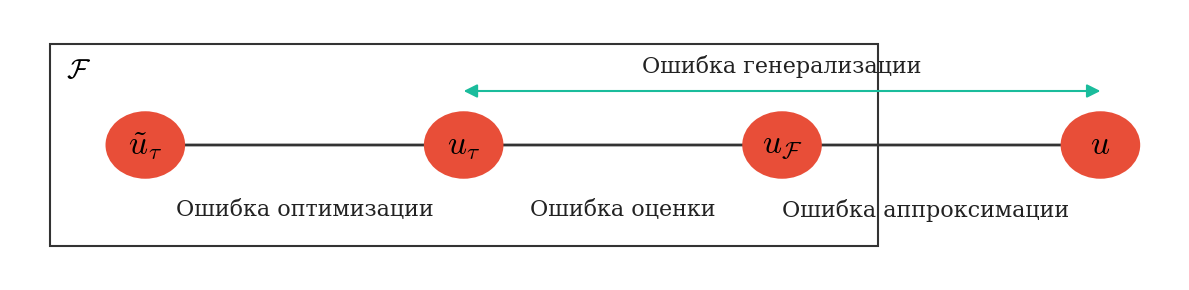

In [39]:
create_pinnacle_diagram()

In [8]:
# !pip install deepxde

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import sys
from pathlib import Path

project_root = Path().resolve().parents[0]
print(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# IEEE-стиль из проекта
from pinnacle.src.visualization.ieee_style import setup_ieee_style, save_figure
from pinnacle.deepxde.geometry import sampler as dde_sampler
from pinnacle.deepxde.geometry.glt import GoodLatticeSampler

No backend selected.
Finding available backend...
Found pytorch
Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


C:\Users\alex\Documents\GitHub\PINN
Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Using backend: pytorch



In [10]:
# ----------------------------
# Helpers: sampling in [0,1]^2
# ----------------------------
def lhs_numpy(n, dim=2, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    cut = np.linspace(0, 1, n + 1)
    u = rng.random((n, dim))
    a = cut[:n]
    b = cut[1:n + 1]
    pts = np.zeros_like(u)
    for j in range(dim):
        pts[:, j] = u[:, j] * (b - a) + a
        rng.shuffle(pts[:, j])
    return pts

def chebyshev_1d(n):
    k = np.arange(1, n + 1)
    roots = np.cos((2 * k - 1) * np.pi / (2 * n))
    return 0.5 * (roots + 1.0)  # map [-1,1] -> [0,1]

def grid_2d(n_side):
    xs = np.linspace(0, 1, n_side)
    ys = np.linspace(0, 1, n_side)
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    return np.column_stack([X.ravel(), Y.ravel()])

def chebyshev_grid_2d(n_side):
    xs = chebyshev_1d(n_side)
    ys = chebyshev_1d(n_side)
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    return np.column_stack([X.ravel(), Y.ravel()])

def fbpinn_random(n, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    return rng.random((n, 2))

def fbpinn_mesh(n_side):
    return grid_2d(n_side)

Using SciencePlots style (science + ieee + grid)


c:\Users\alex\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+90=90. 
  warnings.warn(


Figure saved to: docs\glt_visualization_grid.pdf


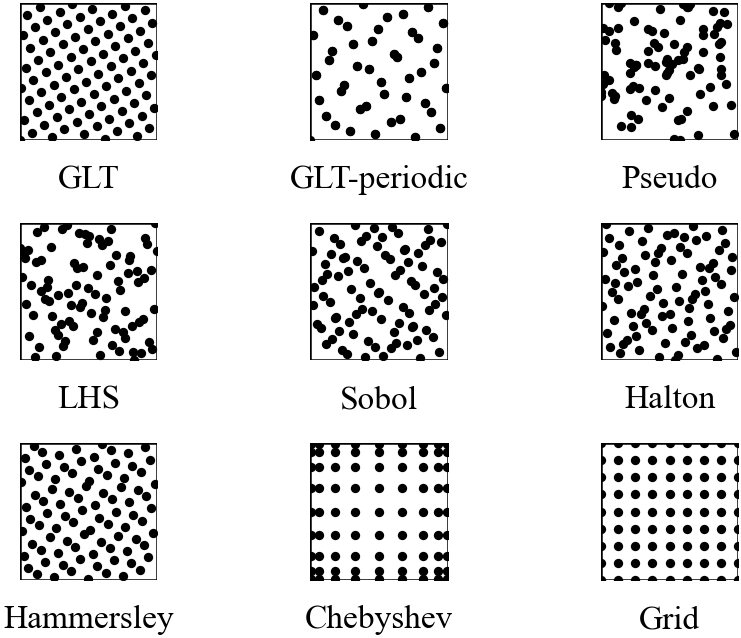

In [20]:
# ----------------------------
# Methods (все, что обсуждали)
# ----------------------------
N = 89
N_SIDE = int(math.sqrt(N))  # 12

# methods = [
#     ("GLT", lambda: dde_sampler.sample(N, 2, "GLT")),
#     # ("GLT-rand", lambda: dde_sampler.sample(N, 2, "GLT-rand")),
#     ("GLT-periodic", lambda: GoodLatticeSampler(dim=2, n_points=N).sample(fold_axes=[0, 1])),
#     ("Pseudo", lambda: dde_sampler.sample(N, 2, "pseudo")),
#     ("LHS", lambda: dde_sampler.sample(N, 2, "LHS")),
#     ("Sobol", lambda: dde_sampler.sample(N, 2, "Sobol")),
#     ("Halton", lambda: dde_sampler.sample(N, 2, "Halton")),
#     ("Hammersley", lambda: dde_sampler.sample(N, 2, "Hammersley")),
#     # ("FBPINN-random", lambda: fbpinn_random(N)),
#     # ("Mesh", lambda: fbpinn_mesh(N_SIDE)),
#     ("Random", lambda: fbpinn_random(N)),
#     ("Latin", lambda: lhs_numpy(N, 2)),
#     ("Chebyshev", lambda: chebyshev_grid_2d(N_SIDE)),
#     ("Grid", lambda: grid_2d(N_SIDE)),
# ]


methods = [
    ("GLT", lambda: dde_sampler.sample(N, 2, "GLT")),
    ("GLT-periodic", lambda: GoodLatticeSampler(dim=2, n_points=N).sample(fold_axes=[0, 1])),
    ("Pseudo", lambda: dde_sampler.sample(N, 2, "pseudo")),
    ("LHS", lambda: dde_sampler.sample(N, 2, "LHS")),
    ("Sobol", lambda: dde_sampler.sample(N, 2, "Sobol")),
    ("Halton", lambda: dde_sampler.sample(N, 2, "Halton")),
    ("Hammersley", lambda: dde_sampler.sample(N, 2, "Hammersley")),
    ("Chebyshev", lambda: chebyshev_grid_2d(N_SIDE)),
    ("Grid", lambda: grid_2d(N_SIDE)),
]


# ----------------------------
# Figure layout
# ----------------------------
setup_ieee_style(column_width="single", font_size=8, use_scienceplots=True)

n = len(methods)
ncols = 3
nrows = math.ceil(n / ncols)

fig = plt.figure(figsize=(3.5, 2.5))
gs = fig.add_gridspec(nrows=nrows, ncols=ncols, wspace=0.25, hspace=0.6)

for i, (name, sampler_fn) in enumerate(methods):
    r, c = divmod(i, ncols)
    ax = fig.add_subplot(gs[r, c])

    pts = sampler_fn()

    # квадратный патч расчетной области
    ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor="black", linewidth=0.6))

    # крупные чёрные точки
    ax.scatter(pts[:, 0], pts[:, 1], s=5, c="black", marker="o", linewidths=0)

    # без осей
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

    # подпись
    ax.text(0.5, -0.18, name, ha="center", va="top", transform=ax.transAxes)

# если осталось пустое место — выключаем оси
for j in range(n, nrows * ncols):
    r, c = divmod(j, ncols)
    ax = fig.add_subplot(gs[r, c])
    ax.axis("off")

save_figure(fig, "docs/glt_visualization_grid.pdf")